# NRT threshold selection

Chooses the probability threshold of the near real time rule, from the per-acquisition
scores written by `nrt_scores.py`. It answers two questions: does the score separate the
acquisitions before an event from those after it, and does the joint mode separate them
better than the optical one.

It does **not** measure timeliness. Applying the rule to each polygon and comparing its
alert date with VIEW_DATE is a separate step, run on the test split once the threshold
here is fixed.

Copy `nrt_scores/` from the cluster next to this notebook first. `nrt_roc.py` produces the
same curves as a script; this notebook is for looking at the numbers before fixing them.

In [3]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

SCORES = 'nrt_scores'          # folder copied from the cluster
TAG    = 'trainval'            # THE TRAINING SPLIT, and only it: the threshold is
                               # chosen here. The test scores live under TAG='test'
                               # and are read by nrt_timing.py, never here.
MODEL, VER = 'log_reg', '3'    # the model the sections below use by default
MODELS = ['log_reg', 'rf']     # both, for the model comparison of section 6
MODES  = ['optical', 'joint']
COL = {'optical': '#eb6834', 'joint': '#2a78d6'}


def load(mode, model=MODEL, ver=VER, tag=TAG):
    """One frame per (mode, model).

    Two keys, and they answer different questions. `date` is when the observation
    became available: a joint pair is dated by the later of its two acquisitions,
    since it does not exist until both images have been taken, so it is the key for
    anything about timeliness. `s2_id` is the Sentinel-2 image behind the row, and it
    is the key that matches a joint observation with the optical one built on the
    same image, which dates cannot do.
    """
    folder = f'{mode}_{model}_v{ver}' + (f'_{tag}' if tag else '')
    files = glob.glob(f'{SCORES}/{folder}/fid_*.csv')
    if not files:
        raise FileNotFoundError(f'{SCORES}/{folder}/ is empty')
    frame = pd.concat(map(pd.read_csv, files), ignore_index=True)
    if 's2_id' not in frame.columns:
        raise KeyError(f'{folder}: no s2_id column. Regenerate the scores: '
                       f'rm -rf nrt_scores/*_v{ver}_{tag} && TAG={tag} ./run_scores.sh')
    return frame


d = {m: load(m) for m in MODES}
print(f'{TAG} / {MODEL}: ' + ' | '.join(f'{m} {len(d[m])} rows' for m in MODES))
d['optical'].head()

trainval / log_reg: optical 2263 rows | joint 1445 rows


,date,win,s2_id,n_tok,p_sum,n_nonforest,n_tiles,pc_sum,p_dist,p_class,fid,mode,model,view_date,days
0,2023-04-30,bef,20230430T142719_20230430T142714_T20LNR,28,8.584589,4,4,1.769166,0.306592,0.063184,327,optical,log_reg,2023-08-15,-107
1,2023-05-15,bef,20230515T142711_20230515T142713_T20LNR,28,13.539002,11,4,3.982097,0.483536,0.142218,327,optical,log_reg,2023-08-15,-92
2,2023-06-04,bef,20230604T142721_20230604T142716_T20LNR,28,11.009270,11,4,1.810979,0.393188,0.064678,327,optical,log_reg,2023-08-15,-72
3,2023-06-09,bef,20230609T142719_20230609T142938_T20LNR,28,8.243740,4,4,2.128912,0.294419,0.076033,327,optical,log_reg,2023-08-15,-67
4,2023-06-19,bef,20230619T142719_20230619T142934_T20LNR,28,4.580670,4,4,1.018101,0.163595,0.036361,327,optical,log_reg,2023-08-15,-57


## 1. Are the two samples comparable?

The joint series needs a Sentinel-1 acquisition paired to each Sentinel-2 one, so it holds
fewer dates. If the two modes cover different polygons or different dates, a difference
between their curves cannot be attributed to the representation.

In [4]:
for m, x in d.items():
    print(f'{m:8s}: {x.fid.nunique():3d} polygons | {len(x):5d} acquisitions | '
          f'{(x.win == "aft").sum():4d} after ({(x.win == "aft").mean():.1%})')

o, j = d['optical'], d['joint']
print('\nonly in optical:', sorted(set(o.fid) - set(j.fid)))
print('only in joint  :', sorted(set(j.fid) - set(o.fid)))

# Matched on the Sentinel-2 image, not on the date. A joint pair is dated by the
# later of its two acquisitions, so the same optical image carries a different date
# in the two modes and a join on dates would miss most of the pairs.
ok, jk = o.dropna(subset=['s2_id']), j.dropna(subset=['s2_id'])
ko, kj = set(zip(ok.fid, ok.s2_id)), set(zip(jk.fid, jk.s2_id))
print(f'\nshared Sentinel-2 images: {len(ko & kj)}')
print(f'  optical only           : {len(ko - kj)}')
print(f'  joint only             : {len(kj - ko)}   <- should be 0')

optical : 174 polygons |  2263 acquisitions |  341 after (15.1%)
joint   : 173 polygons |  1445 acquisitions |  193 after (13.4%)

only in optical: [224]
only in joint  : []

shared Sentinel-2 images: 1439
  optical only           : 824
  joint only             : 0   <- should be 0


## 2. ROC and precision recall

`bef` is the negative class and `aft` the positive one. The event window straddles the
reference date, so it is dropped. `buffer` additionally drops the before acquisitions that
fall within that many days of the reference date.

In [5]:
def curves(x, buffer=0, match=None):
    x = x[x.win != 'evt']
    if match is not None:
        # keyed on the Sentinel-2 image, so the two modes are compared on the same
        # optical input rather than on dates that do not mean the same thing
        x = x[[k in match for k in zip(x.fid, x.s2_id)]]
    if buffer:
        x = x[(x.win == 'aft') | (x.days <= -buffer)]
    y = (x.win == 'aft').astype(int)
    fpr, tpr, thr = roc_curve(y, x.p_dist)
    prec, rec, _ = precision_recall_curve(y, x.p_dist)
    return dict(fpr=fpr, tpr=tpr, thr=thr, prec=prec, rec=rec,
                auc=roc_auc_score(y, x.p_dist),
                ap=average_precision_score(y, x.p_dist),
                n=len(x), pos=y.mean())

## 3. The modes at an equal false alarm rate

The two modes produce probabilities from different classifiers, so the same threshold does
not mean the same thing in both. This is the comparison that answers whether radar adds
anything.

In [6]:
for target in [0.02, 0.05, 0.10]:
    print(f'--- false alarm rate {target:.0%}')
    for m in MODES:
        c = curves(d[m])
        i = min(int(np.searchsorted(c['fpr'], target)), len(c['thr']) - 1)
        print(f'  {m:8s} tau {c["thr"][i]:.3f} -> detection {c["tpr"][i]:.3f}')
    print()

--- false alarm rate 2%
  optical  tau 0.987 -> detection 0.196
  joint    tau 0.988 -> detection 0.202

--- false alarm rate 5%
  optical  tau 0.970 -> detection 0.428
  joint    tau 0.972 -> detection 0.399

--- false alarm rate 10%
  optical  tau 0.943 -> detection 0.630
  joint    tau 0.948 -> detection 0.565



## 4. Matched Sentinel-2 images

Same as above but restricted to the optical images present in both modes, so the
comparison isolates the representation instead of the number of observations each mode
has. The match is on the Sentinel-2 image and not on the date, because a joint pair is
dated by the later of its two acquisitions and therefore does not share the date of the
optical observation built on the same image.

One caveat on what this isolates: the joint row carries the same optical image **plus** a
radar image from another day, so it holds strictly more information. The comparison
answers whether adding radar to a given optical image helps, not whether two equivalent
inputs are encoded differently.

In [7]:
shared = ko & kj
for m in MODES:
    c = curves(d[m], match=shared)
    i = int(np.argmax(c['tpr'] - c['fpr']))
    print(f'{m:8s} rows {c["n"]:5d} | AUC {c["auc"]:.3f} | AP {c["ap"]:.3f} | '
          f'tau {c["thr"][i]:.3f} -> detection {c["tpr"][i]:.3f}, '
          f'false alarm {c["fpr"][i]:.3f}')

optical  rows  1305 | AUC 0.888 | AP 0.558 | tau 0.860 -> detection 0.880, false alarm 0.229
joint    rows  1311 | AUC 0.886 | AP 0.542 | tau 0.851 -> detection 0.896, false alarm 0.265


## 5. How much signal is there before the reference date?

The reference date is when DETER detected the event, not when it happened. Dropping the
before acquisitions closest to it should lower the false alarm rate if part of what is
counted as a false alarm is in fact an early detection. Where the rate stops falling is an
estimate of how much earlier the signal appears.

In [8]:
rows = []
for m in MODES:
    for b in [0, 15, 30, 45, 60, 90]:
        c = curves(d[m], buffer=b)
        i = int(np.argmax(c['tpr'] - c['fpr']))
        rows.append(dict(mode=m, buffer=b, rows=c['n'], positives=round(c['pos'], 3),
                         auc=round(c['auc'], 3), tau=round(c['thr'][i], 3),
                         detection=round(c['tpr'][i], 3),
                         false_alarm=round(c['fpr'][i], 3)))

sweep = pd.DataFrame(rows)
sweep

,mode,buffer,rows,positives,auc,tau,detection,false_alarm
0,optical,0,2003,0.170,0.891,0.842,0.903,0.258
1,optical,15,1913,0.178,0.900,0.842,0.903,0.242
2,optical,30,1648,0.207,0.912,0.842,0.903,0.216
3,optical,45,1429,0.239,0.915,0.842,0.903,0.208
4,optical,60,1209,0.282,0.917,0.842,0.903,0.207
5,optical,90,815,0.418,0.923,0.842,0.903,0.196
6,joint,0,1311,0.147,0.886,0.851,0.896,0.265
7,joint,15,1242,0.155,0.898,0.851,0.896,0.246
8,joint,30,1084,0.178,0.905,0.862,0.881,0.214
9,joint,45,945,0.204,0.910,0.862,0.881,0.206


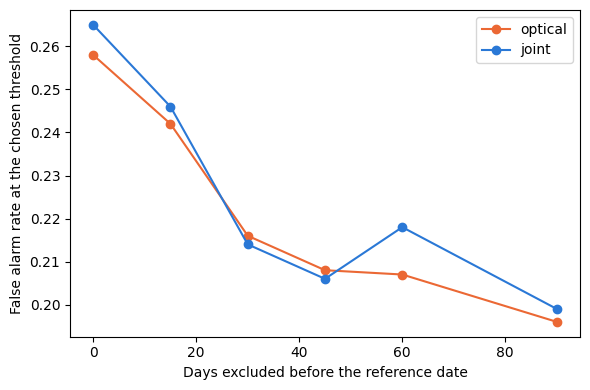

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in MODES:
    s = sweep[sweep['mode'] == m]
    ax.plot(s.buffer, s.false_alarm, 'o-', color=COL[m], label=m)
ax.set_xlabel('Days excluded before the reference date')
ax.set_ylabel('False alarm rate at the chosen threshold')
ax.legend()
plt.tight_layout()

In [10]:
x = d['optical']
x = x[x.win == 'bef']
top = x.nlargest(40, 'p_dist')[['fid', 'date', 'days', 'p_dist', 'p_class']]
print(top.days.describe())
top.head(20)

count     40.000000
mean     -48.825000
std       46.768874
min     -202.000000
25%      -59.500000
50%      -32.000000
75%      -15.750000
max      -11.000000
Name: days, dtype: float64


,fid,date,days,p_dist,p_class
242,296,2023-06-04,-12,0.995171,0.899411
489,286,2023-04-30,-15,0.994948,0.958715
1963,80,2023-08-23,-21,0.994481,0.781061
64,350,2023-04-30,-142,0.994216,0.906521
240,296,2023-05-15,-32,0.993976,0.873860
65,350,2023-05-15,-127,0.993778,0.890538
1964,80,2023-08-28,-16,0.992922,0.754986
1103,108,2023-05-15,-14,0.992810,0.948820
67,350,2023-06-09,-102,0.991694,0.900349
2159,210,2023-07-29,-12,0.991540,0.823994


In [11]:
x = d['optical']
bef = x[x.win == 'bef']
print('todas las anteriores :', bef.days.describe()[['count','25%','50%','75%']].to_dict())
print('las 40 mayores       :', bef.nlargest(40, 'p_dist').days.describe()[['25%','50%','75%']].to_dict())

todas las anteriores : {'count': 1662.0, '25%': -96.0, '50%': -62.0, '75%': -32.0}
las 40 mayores       : {'25%': -59.5, '50%': -32.0, '75%': -15.75}


## 6. The two classifiers, on one common evaluation set

Sections 2 to 5 use one model at a time. This section compares the linear probe with the
random forest, and the two modes, on a single set of observations: the Sentinel-2 images
present in all four score sets.

Two reasons for the common set. First, average precision depends on the share of positives,
so comparing it across sets with different prevalence measures the prevalence and not the
model; `ap_over_baseline` divides it by that share to make the number readable. Second, the
four score sets do not otherwise contain the same acquisitions, and a difference in
coverage would be read as a difference in skill.

AUC is prevalence independent, so it is the number to quote when the sets differ.

In [12]:
data = {}
for model in MODELS:
    for mode in MODES:
        data[(mode, model)] = load(mode, model=model)

keys = set.intersection(*(set(zip(y.fid, y.s2_id))
                          for y in (x.dropna(subset=['s2_id'])
                                    for x in data.values())))
print(f'Sentinel-2 images common to the four score sets: {len(keys)}')

rows = []
for (mode, model), x in data.items():
    c = curves(x, match=keys)
    i = int(np.argmax(c['tpr'] - c['fpr']))
    rows.append(dict(mode=mode, model=model, n=c['n'],
                     positives=round(c['pos'], 3),
                     auc=round(c['auc'], 3),
                     ap=round(c['ap'], 3),
                     ap_over_baseline=round(c['ap'] / c['pos'], 2),
                     tau=round(c['thr'][i], 3),
                     detection=round(c['tpr'][i], 3),
                     false_alarm=round(c['fpr'][i], 3)))

matched = pd.DataFrame(rows).sort_values(['mode', 'model']).reset_index(drop=True)
print()
print(matched.to_string(index=False))
print()
print('n and positives must be identical in the four rows; if not, the match failed.')

Sentinel-2 images common to the four score sets: 1439

   mode   model    n  positives   auc    ap  ap_over_baseline   tau  detection  false_alarm
  joint log_reg 1311      0.147 0.886 0.542              3.68 0.851      0.896        0.265
  joint      rf 1311      0.147 0.955 0.795              5.40 0.856      0.922        0.126
optical log_reg 1305      0.147 0.888 0.558              3.79 0.860      0.880        0.229
optical      rf 1305      0.147 0.954 0.776              5.27 0.818      0.948        0.149

n and positives must be identical in the four rows; if not, the match failed.


In [13]:
# the operating points quoted in the write up, on the same common set
for target in [0.02, 0.05, 0.10]:
    print(f'--- false alarm rate {target:.0%}')
    for (mode, model), x in sorted(data.items()):
        c = curves(x, match=keys)
        i = min(int(np.searchsorted(c['fpr'], target)), len(c['thr']) - 1)
        print(f'  {mode:8s} {model:8s} tau {c["thr"][i]:.3f} '
              f'-> detection {c["tpr"][i]:.3f}')
    print()

--- false alarm rate 2%
  joint    log_reg  tau 0.988 -> detection 0.202
  joint    rf       tau 0.932 -> detection 0.523
  optical  log_reg  tau 0.988 -> detection 0.172
  optical  rf       tau 0.933 -> detection 0.505

--- false alarm rate 5%
  joint    log_reg  tau 0.972 -> detection 0.399
  joint    rf       tau 0.913 -> detection 0.689
  optical  log_reg  tau 0.972 -> detection 0.401
  optical  rf       tau 0.906 -> detection 0.693

--- false alarm rate 10%
  joint    log_reg  tau 0.948 -> detection 0.565
  joint    rf       tau 0.874 -> detection 0.870
  optical  log_reg  tau 0.944 -> detection 0.604
  optical  rf       tau 0.843 -> detection 0.880



## 7. Test split, at the threshold fixed on training

Everything above is the training split: it is where the threshold is chosen, and it is
also where the classifiers were fitted, so a score measured there is optimistic on two
counts. The random forest in particular can memorise the tokens it was trained on, which
is the likely reason its training AUC sits so far above the linear probe.

This section is the one to report. The threshold comes from the training curves at a fixed
false alarm rate and is never re-selected here; the test acquisitions are read once, at
that threshold.

Both scopes are given: `all` lets each mode keep its own observations, which is what each
system would see in operation, and `matched` restricts the two to the Sentinel-2 images
they share, which isolates the representation from the coverage.

In [15]:
TARGET_FA = 0.05      # operating point, fixed on the training split

# 1. thresholds from training, at an equal false alarm rate for every mode and model
tau = {}
for (mode, model), x in data.items():
    c = curves(x, match=keys)
    i = min(int(np.searchsorted(c['fpr'], TARGET_FA)), len(c['thr']) - 1)
    tau[(mode, model)] = float(c['thr'][i])

# 2. the test split, which chooses nothing
test = {(mode, model): load(mode, model=model, tag='test')
        for model in MODELS for mode in MODES}
tkeys = set.intersection(*(set(zip(y.fid, y.s2_id))
                           for y in (x.dropna(subset=['s2_id']) for x in test.values())))
print(f'test: {len(tkeys)} Sentinel-2 images common to the four score sets')

rows = []
for (mode, model), x in test.items():
    for scope, match in (('all', None), ('matched', tkeys)):
        z = x[x.win != 'evt']
        if match is not None:
            z = z[[k in match for k in zip(z.fid, z.s2_id)]]
        y = (z.win == 'aft').astype(int)
        t = tau[(mode, model)]
        flag = z.p_dist >= t
        rows.append(dict(scope=scope, mode=mode, model=model,
                         n=len(z), polygons=z.fid.nunique(),
                         positives=round(y.mean(), 3),
                         auc=round(roc_auc_score(y, z.p_dist), 3),
                         ap=round(average_precision_score(y, z.p_dist), 3),
                         tau=round(t, 3),
                         detection=round(flag[y == 1].mean(), 3),
                         false_alarm=round(flag[y == 0].mean(), 3)))

test_table = pd.DataFrame(rows).sort_values(['scope', 'mode', 'model']).reset_index(drop=True)
print()
print(test_table.to_string(index=False))
print()
print(f'false_alarm should land near {TARGET_FA:.0%} if the threshold generalises;')
print('a much higher value means the operating point was fitted to the training split.')

test: 1320 Sentinel-2 images common to the four score sets

  scope    mode   model    n  polygons  positives   auc    ap   tau  detection  false_alarm
    all   joint log_reg 1200       169      0.157 0.843 0.503 0.972      0.346        0.048
    all   joint      rf 1200       169      0.157 0.878 0.607 0.913      0.473        0.046
    all optical log_reg 1831       169      0.191 0.878 0.644 0.972      0.354        0.030
    all optical      rf 1831       169      0.191 0.894 0.706 0.906      0.474        0.026
matched   joint log_reg 1200       169      0.157 0.843 0.503 0.972      0.346        0.048
matched   joint      rf 1200       169      0.157 0.878 0.607 0.913      0.473        0.046
matched optical log_reg 1196       169      0.157 0.861 0.559 0.972      0.351        0.031
matched optical      rf 1196       169      0.157 0.873 0.617 0.906      0.441        0.030

false_alarm should land near 5% if the threshold generalises;
a much higher value means the operating point was